In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [2]:
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
x = air_quality.data.features 
y = air_quality.data.targets
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

# Load data

In [3]:
path = kagglehub.dataset_download("joebeachcapital/top-500-hollywood-movies-of-all-time")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
movies_df = pd.read_csv(os.path.join(path, "Most Profitable Movies of All Time - Top 500 Movies.csv"))

movies_df.head()

,title,worldwide gross (m),% budget recovered,X times budget recovered,budget (millions),domestic gross (m),domestic %,international gross (m),% of gross from international,worldwide gross,year,decade,source,budget source,force label,horror
0,300,456.0,702%,7.0,65.0,211.0,46.2%,245.0,53.8%,456082343,2007,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
1,1917,385.0,427%,4.3,90.0,159.0,41.4%,225.0,58.6%,384576334,2019,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://www.nytimes.com/2020/01/12/movies/1917...,NaN,not horror
2,2012,791.0,396%,4.0,200.0,166.0,21.0%,625.0,79.0%,791217826,2009,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
3,101 Dalmatians,321.0,479%,4.8,67.0,136.0,42.5%,185.0,57.5%,320689294,1996,1990's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://en.wikipedia.org/wiki/101_Dalmatians_(...,NaN,not horror
4,22 Jump Street,331.0,663%,6.6,50.0,192.0,57.9%,140.0,42.1%,331333876,2014,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror


# Data cleaning

In [4]:
# cek missing values
missing_values = movies_df.isnull().sum()

# cek duplicate rows
duplicate_rows = movies_df.duplicated().sum()

# cek data types
data_types = movies_df.dtypes

missing_values, duplicate_rows, data_types

(title                              0
 worldwide gross (m)                0
 % budget recovered                 0
 X times budget recovered           0
 budget  (millions)                 0
 domestic gross (m)                 0
 domestic %                         0
 international gross (m)            0
 % of gross from international      0
 worldwide gross                    0
 year                               0
 decade                             0
 source                            81
 budget source                    163
 force label                      557
 horror                             0
 dtype: int64,
 np.int64(0),
 title                                str
 worldwide gross (m)              float64
 % budget recovered                   str
 X times budget recovered         float64
 budget  (millions)               float64
 domestic gross (m)               float64
 domestic %                           str
 international gross (m)          float64
 % of gross from internatio

In [5]:
# drop 'force label' column karena banyak missing values
movies_df.drop(columns=['force label'], inplace=True)

# convert percentage columns menjadi numerical types
percentage_columns = ['% budget recovered', 'domestic %', '% of gross from international']
for col in percentage_columns:
    movies_df[col] = movies_df[col].str.rstrip('%').astype('float') / 100

movies_df.head()

,title,worldwide gross (m),% budget recovered,X times budget recovered,budget (millions),domestic gross (m),domestic %,international gross (m),% of gross from international,worldwide gross,year,decade,source,budget source,horror
0,300,456.0,7.02,7.0,65.0,211.0,0.462,245.0,0.538,456082343,2007,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,not horror
1,1917,385.0,4.27,4.3,90.0,159.0,0.414,225.0,0.586,384576334,2019,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://www.nytimes.com/2020/01/12/movies/1917...,not horror
2,2012,791.0,3.96,4.0,200.0,166.0,0.210,625.0,0.790,791217826,2009,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,not horror
3,101 Dalmatians,321.0,4.79,4.8,67.0,136.0,0.425,185.0,0.575,320689294,1996,1990's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://en.wikipedia.org/wiki/101_Dalmatians_(...,not horror
4,22 Jump Street,331.0,6.63,6.6,50.0,192.0,0.579,140.0,0.421,331333876,2014,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,not horror


## EDA

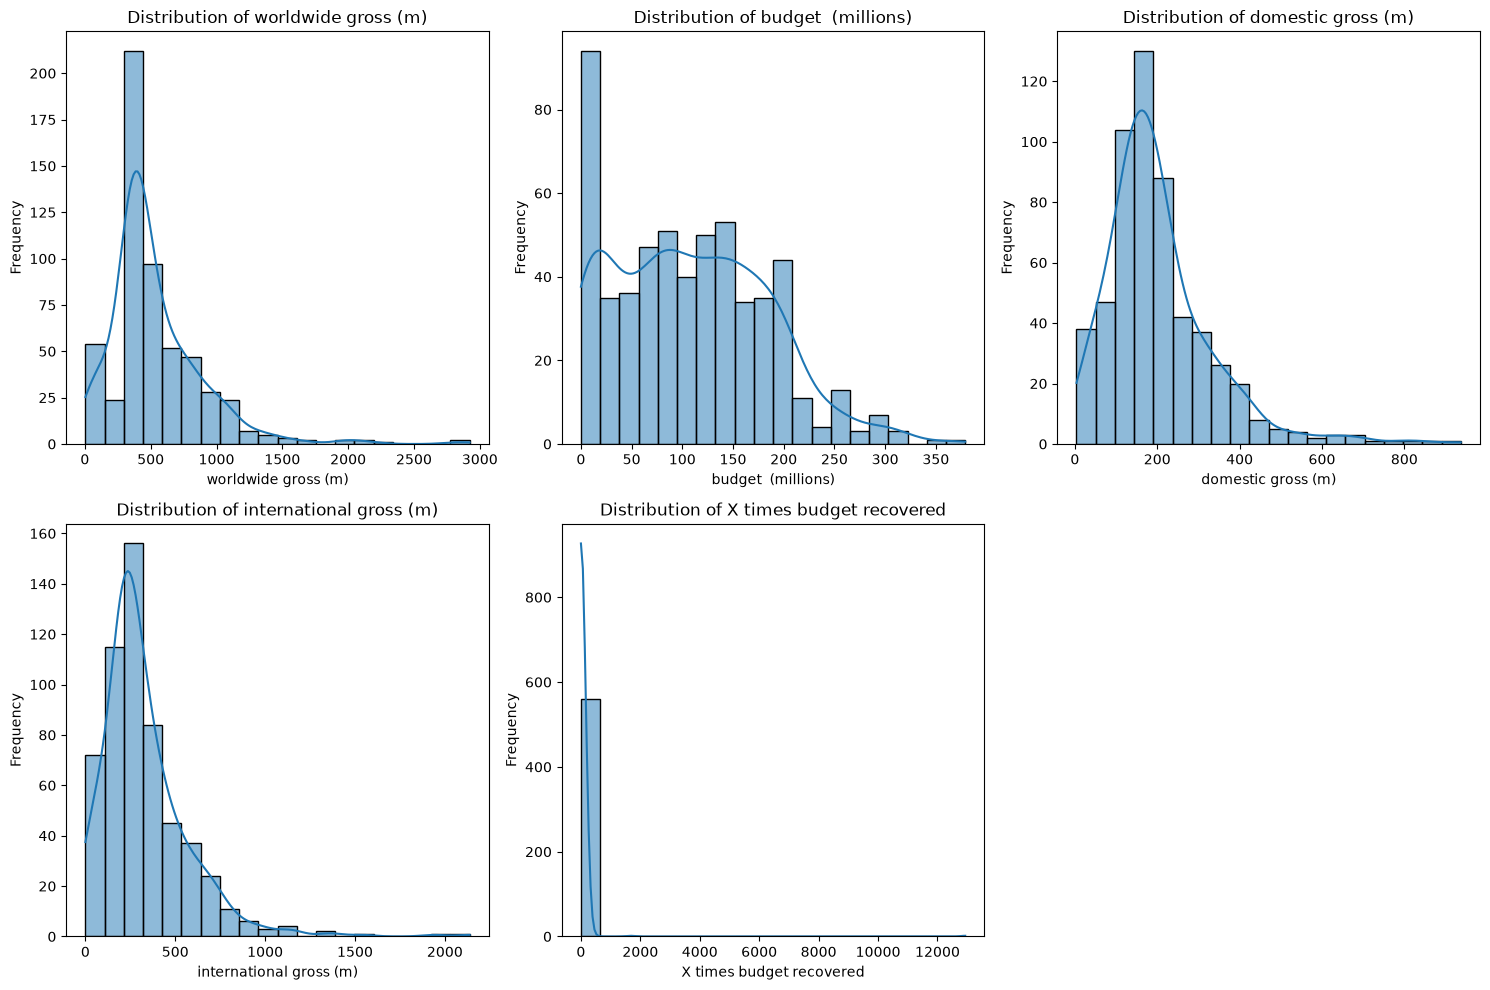

In [6]:
# list numerical variables
numerical_columns = [
    'worldwide gross (m)',
    'budget  (millions)',
    'domestic gross (m)',
    'international gross (m)',
    'X times budget recovered'
]

# histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(movies_df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

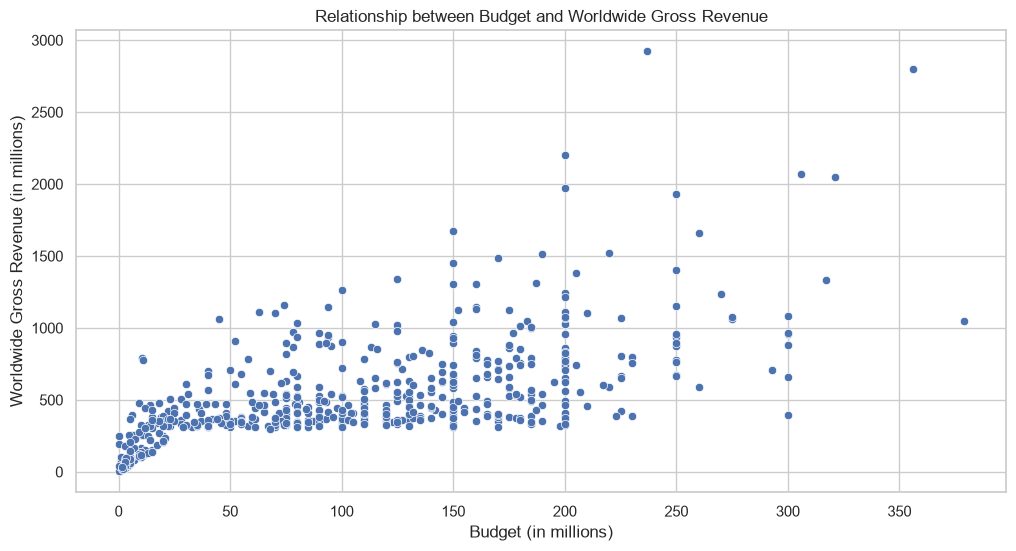

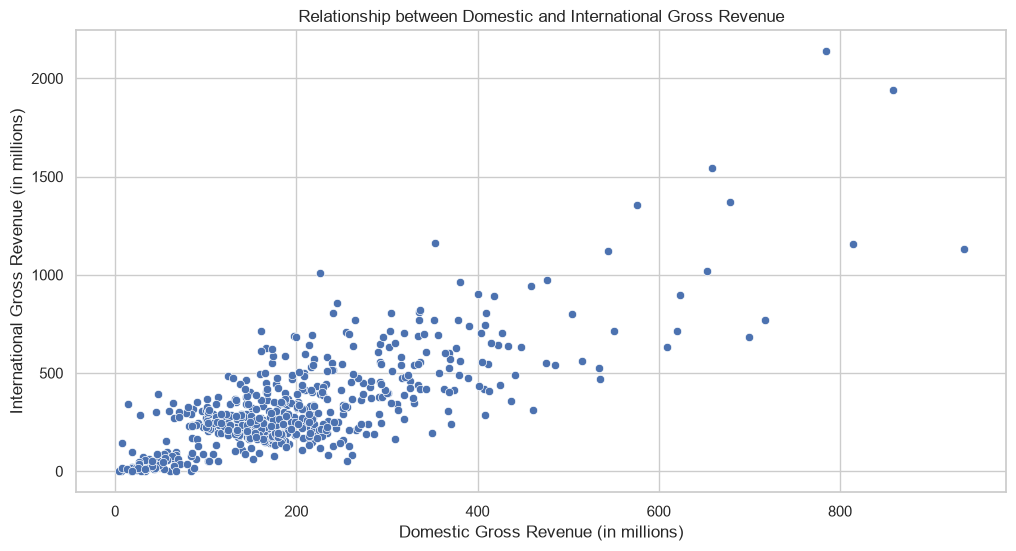

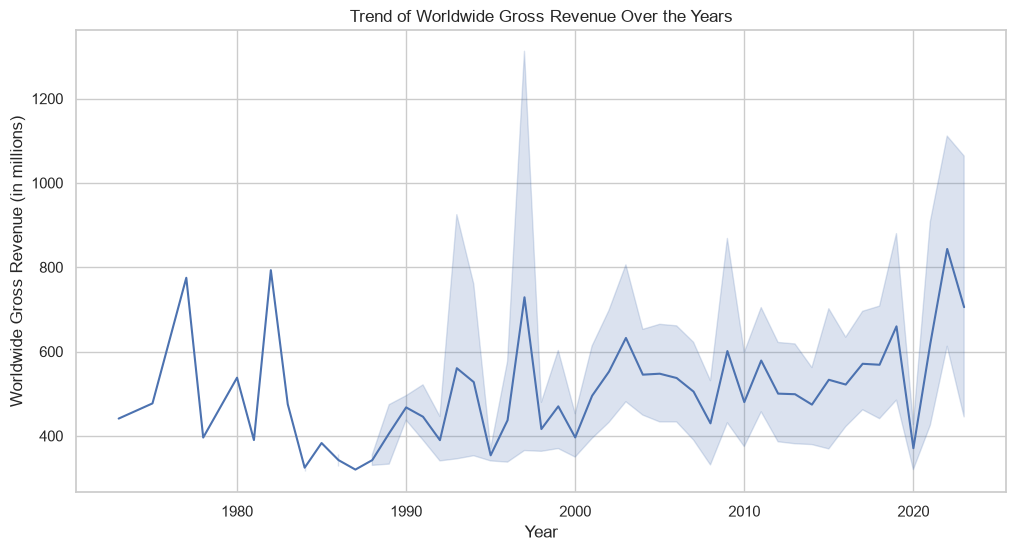

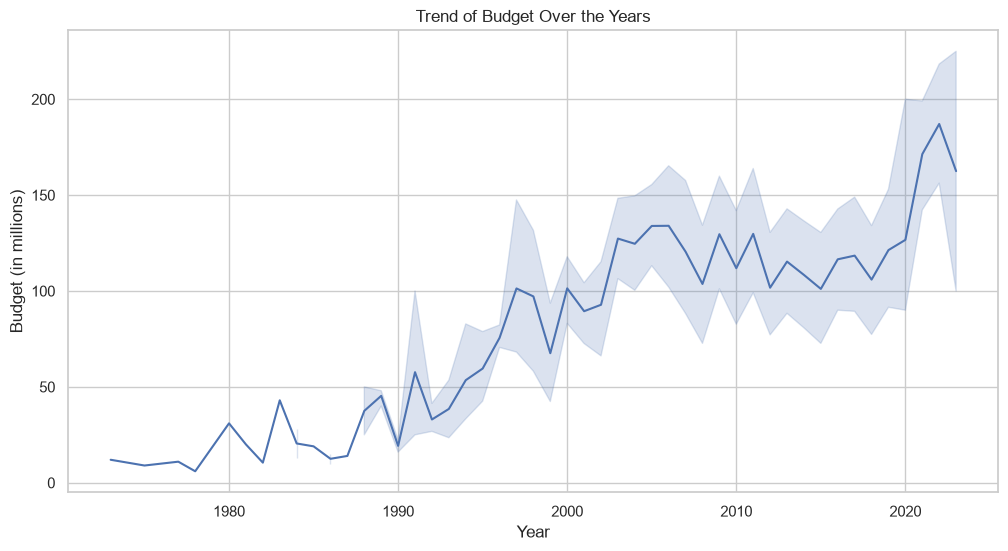

In [9]:
# plotting hubungan antara budget dan worldwide gross revenue
plt.figure(figsize=(12, 6))
sns.scatterplot(x='budget  (millions)', y='worldwide gross (m)', data=movies_df)
plt.title('Relationship between Budget and Worldwide Gross Revenue')
plt.xlabel('Budget (in millions)')
plt.ylabel('Worldwide Gross Revenue (in millions)')
plt.show()

# Plotting hubungan antara domestic dan international gross revenue
plt.figure(figsize=(12, 6))
sns.scatterplot(x='domestic gross (m)', y='international gross (m)', data=movies_df)
plt.title('Relationship between Domestic and International Gross Revenue')
plt.xlabel('Domestic Gross Revenue (in millions)')
plt.ylabel('International Gross Revenue (in millions)')
plt.show()

# Plotting tren dari worldwide gross revenue over the years
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='worldwide gross (m)', data=movies_df)
plt.title('Trend of Worldwide Gross Revenue Over the Years')
plt.xlabel('Year')
plt.ylabel('Worldwide Gross Revenue (in millions)')
plt.show()

# Plotting tren dari budget over the years
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='budget  (millions)', data=movies_df)
plt.title('Trend of Budget Over the Years')
plt.xlabel('Year')
plt.ylabel('Budget (in millions)')
plt.show()

# Uji asumsi

In [ ]:
# tema grafik
sns.set_theme(style="whitegrid")

# model
formula = "worldwide gross (m) ~ budget  (millions)"
# fit model OLS
model = ols(formula, data=df).fit()

# ringkasan hasil regresi
print(model.summary())
print("="*60)

SyntaxError: invalid syntax (<unknown>, line 1)

## Uji normalitas residual (Jarque-Bera, Saphiro-Wilk)

In [ ]:
residuals = model.resid

jb_stat, jb_pvalue = jarque_bera(residuals)[0], jarque_bera(residuals)[1]
shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)

print("Uji normalitas:")
print(f"Jarque-Bera p-value: {jb_pvalue:.4f} -> {'Normal' if jb_pvalue > 0.05 else 'Tidak Normal'}")
print(f"Shapiro-Wilk p-value: {shapiro_pvalue:.4f} -> {'Normal' if shapiro_pvalue > 0.05 else 'Tidak Normal'}")

Uji normalitas:
Jarque-Bera p-value: 0.0000 -> Tidak Normal
Shapiro-Wilk p-value: 0.0000 -> Tidak Normal


c:\Users\ACER\OneDrive - Universitas Diponegoro\kuliah\semester 3\metsam\uji-validitas-reliabilitas\metode-sampling\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 500000.
  res = hypotest_fun_out(*samples, **kwds)
